# Task 5 · Step 1 — In-domain GSM8K comparison

**Feedback sources.** RLVR uses the exact final-answer checker, $r_{\text{RLVR}}(x,y)=\mathbb{1}[\text{verifier}(y)=\text{gold}(x)]$, where the verifier extracts the **last** `#### <number>` field (numbers elsewhere are ignored). RLAIF uses a direct group reward from the fixed pairwise judge: for the $K$ responses to one prompt, $r_{\text{RLAIF}}(y_k)=\frac{\text{wins}(y_k)+0.5\,\text{ties}(y_k)}{K-1}$. The judge (`Qwen2.5-3B-Instruct`, 4-bit, greedy, 4 new tokens) receives the rubric, the problem and two candidates in a deterministic hash-based A/B orientation and must answer A, B or TIE; the released parser keeps the first of A/B/TIE it finds (no match → TIE).

**Policies.** SFT = base `Qwen2.5-1.5B-Instruct`; RLVR and RLAIF = the supplied frozen adapters (same base, same GSM8K prompt indices, group optimiser, group size, completion cap and approximately matched token budget). All policies answer with greedy decoding, cap 512 tokens, using the exact course prompts.

**AI pairwise win rate.** win = 1, tie = 0.5, loss = 0, averaged over the fixed set; explicit ties and ambiguous judge outputs are reported separately.

**Research question (RQ1).** Where does AI preference feedback distinguish responses that the binary verifier treats identically, and when is that extra flexibility useful?


In [1]:
%matplotlib inline
import os, sys, json, re
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from IPython.display import display, Markdown, HTML, Image
from common.nb_helpers import (style, load, jl, exists, pending, run, side_by_side, ci_text,
                               bootstrap_mean_diff, smooth, full_windows, PALETTE, SEQ, RES, FIG)
from common.metrics import length_stats, wilson_interval
from common.data import load_yaml
style()
print("repo root:", ROOT)

repo root: C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA2


## Run this step (optional)
The results below come from the Kaggle run of the script pipeline (`kaggle_runner.ipynb`). Set `FORCE_RUN = True`
to re-run the step's scripts from here (needs a CUDA GPU and the downloaded course assets).


In [2]:
FORCE_RUN = False
if FORCE_RUN:
    run('python -m task5_feedback.evaluate_math --config configs/feedback.yaml --dataset gsm')
    run('python -m task5_feedback.judge_ambiguity --config configs/feedback.yaml')
else:
    print('Using saved results under results/ (FORCE_RUN = False).')

Using saved results under results/ (FORCE_RUN = False).


## 1. Verifier check on the manually validated diagnostic responses

In [3]:
from task5_feedback.rlvr import exact_reward, extract_designated_final
diag = pd.DataFrame(jl_path := [json.loads(l) for l in open("data/task5_controlled_reward_diagnostics.jsonl", encoding="utf-8")])
diag["verifier"] = [exact_reward(r, g) for r, g in zip(diag.response, diag.gold_final)]
diag["expected"] = diag.expected_exact_reward.astype(int)
print(f"verifier matches expected_exact_reward on {(diag.verifier == diag.expected).sum()}/{len(diag)} rows")
pd.crosstab(diag.variant_type, diag.verifier, rownames=["variant"], colnames=["verifier reward"])

verifier matches expected_exact_reward on 100/100 rows


verifier reward,0.0,1.0
variant,,
clean_correct,0,20
corrupt_reasoning_correct_final,0,20
gold_distractor_wrong_final,20,0
good_reasoning_wrong_final,20,0
persuasive_filler_correct,0,20


## 2. Per-policy results

In [4]:
POL = ["sft", "rlvr", "rlaif"]
E = load("task5_feedback/math_eval_gsm.json"); Gn = {p: pd.DataFrame(jl(f"task5_feedback/generations_gsm_{p}.jsonl")) for p in POL}
pd.DataFrame({p.upper(): {"exact accuracy": ci_text(E["per_policy"][p]["exact_accuracy"], E["per_policy"][p]["exact_accuracy_ci95"]),
                          "format compliance": E["per_policy"][p]["format_compliance_rate"], "accuracy | formatted": E["per_policy"][p]["accuracy_given_format"],
                          "length mean ± std": f"{E['per_policy'][p]['length_tokens']['mean']:.0f} ± {E['per_policy'][p]['length_tokens']['std']:.0f}",
                          "hit 512 cap": E["per_policy"][p]["hit_max_tokens_rate"], **{f"share: {k}": v for k, v in E["per_policy"][p]["failure_types"].items()}}
              for p in POL}).T

,exact accuracy,format compliance,accuracy | formatted,length mean ± std,hit 512 cap,share: correct,share: wrong_final_answer,share: no_final_format,share: no_final_format_hit_cap
SFT,"28.3% [24, 34]",0.35,0.8095,274 ± 85,0.0167,0.2833,0.0667,0.6333,0.0167
RLVR,"28.7% [24, 34]",0.36,0.7963,276 ± 86,0.02,0.2867,0.0733,0.62,0.02
RLAIF,"28.7% [24, 34]",0.36,0.7963,275 ± 88,0.0233,0.2867,0.0733,0.6167,0.0233


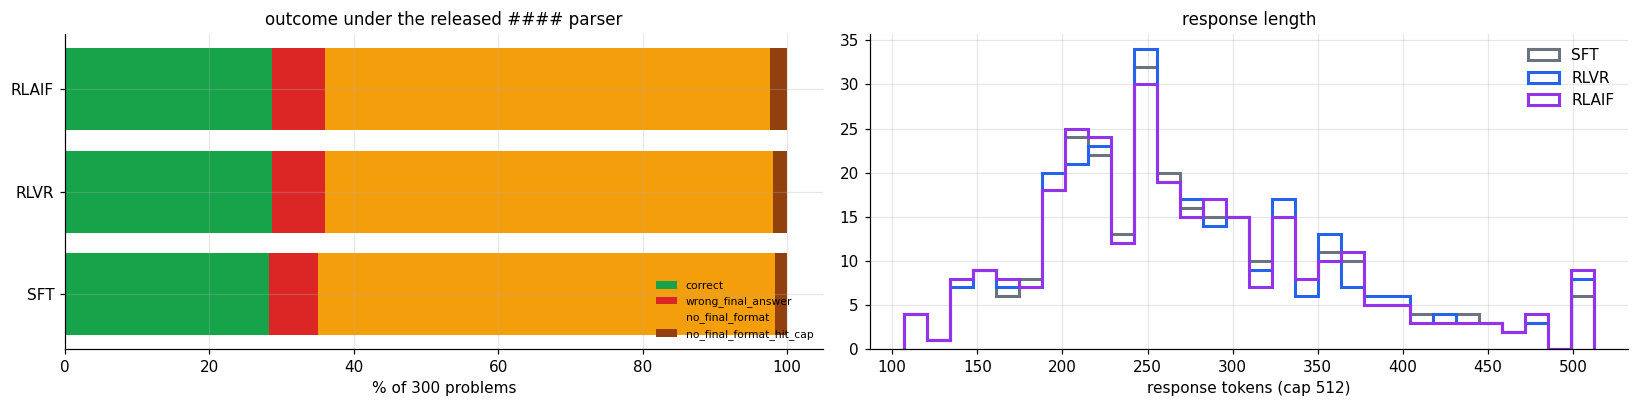

how SFT responses without a `#### <number>` field end: {'**bold**': 76, 'other': 56, '\\boxed{...}': 35, '#### (malformed)': 23}


,gold,response (last 160 chars)
0,9,"already played from her goal:\n\[ \text{Remaining hours} = 30 - 21 = 9 \text{ hours} \]\n\nTherefore, Kris still nee..."
1,4000,"rented over two 4-week months} = 2 \times 500 = 1000 \]\n\nTherefore, the total number of chairs Candy will be able..."
3,144,air.\n\n\[ \text{Total cost} = 12 \times 12 = \$144.00 \]\n\n### Final Answer:\nThe total cost for buying snowshoes ...
4,1600,"umber of popsicle sticks, he should use the cheaper wood, which is the 2 x 4 pieces.\n\nTherefore, the most popsicle..."


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 3.8))
fts = ["correct", "wrong_final_answer", "no_final_format", "no_final_format_hit_cap"]; left = np.zeros(3)
for t, c in zip(fts, ["#16A34A", "#DC2626", "#F59E0B", "#92400E"]):
    v = np.array([E["per_policy"][p]["failure_types"][t] for p in POL]) * 100
    ax[0].barh([p.upper() for p in POL], v, left=left, color=c, label=t); left += v
ax[0].set_xlabel("% of 300 problems"); ax[0].legend(fontsize=7, loc="lower right"); ax[0].set_title("outcome under the released #### parser")
for p, c in zip(POL, ["#6B7280", "#2563EB", "#9333EA"]):
    ax[1].hist(Gn[p].response_tokens, bins=30, histtype="step", lw=2, color=c, label=p.upper())
ax[1].set_xlabel("response tokens (cap 512)"); ax[1].legend(); ax[1].set_title("response length"); fig.tight_layout(); plt.show()
nf = Gn["sft"][Gn["sft"].failure_type == "no_final_format"]
endings = nf.response.str.strip().str[-60:]
kind = np.select([endings.str.contains(r"\\boxed"), endings.str.contains(r"\*\*"), endings.str.contains(r"####")], ["\\boxed{...}", "**bold**", "#### (malformed)"], "other")
print("how SFT responses without a `#### <number>` field end:", pd.Series(kind).value_counts().to_dict())
nf.head(4)[["gold", "response"]].assign(response=lambda d: d.response.str.strip().str[-160:]).rename(columns={"response": "response (last 160 chars)"})

### Supplementary (not the course metric): format-insensitive accuracy
To separate *answer correctness* from *format compliance*, the last number in `\boxed{}`, in a final bold span, or else the last number of the response is compared with the gold answer. This is only a diagnostic of the verifier specification; every reported accuracy above uses the released `####` parser.


In [6]:
def lenient(text):
    t = text.replace(",", "")
    for pat in [r"####\s*([-+]?\d+(?:\.\d+)?)", r"\\boxed\{\s*\$?([-+]?\d+(?:\.\d+)?)", r"\*\*\s*\$?([-+]?\d+(?:\.\d+)?)[^*]*\*\*(?!.*\d)"]:
        m = re.findall(pat, t)
        if m: return m[-1]
    m = re.findall(r"[-+]?\d+(?:\.\d+)?", t); return m[-1] if m else None
ok = lambda a, g: a is not None and abs(float(a) - float(g)) < 1e-6
pd.DataFrame({p.upper(): {"official (####) accuracy": Gn[p].exact_correct.mean(),
                          "format-insensitive accuracy (suppl.)": np.mean([ok(lenient(r), g) for r, g in zip(Gn[p].response, Gn[p].gold)])} for p in POL}).T.round(3)

,official (####) accuracy,format-insensitive accuracy (suppl.)
SFT,0.283,0.663
RLVR,0.287,0.647
RLAIF,0.287,0.660


In [7]:
c = pd.DataFrame({p: Gn[p].exact_correct.values for p in POL})
print("problems solved by all three:", int(c.all(axis=1).sum()), "| by none:", int((~c.any(axis=1)).sum()),
      "| RLVR-only:", int((c.rlvr & ~c.sft & ~c.rlaif).sum()), "| RLAIF-only:", int((c.rlaif & ~c.sft & ~c.rlvr).sum()), "| SFT-only:", int((c.sft & ~c.rlvr & ~c.rlaif).sum()))
print("identical responses: RLVR vs SFT %.2f, RLAIF vs SFT %.2f" % ((Gn["rlvr"].response == Gn["sft"].response).mean(), (Gn["rlaif"].response == Gn["sft"].response).mean()))

problems solved by all three: 79 | by none: 206 | RLVR-only: 5 | RLAIF-only: 2 | SFT-only: 3
identical responses: RLVR vs SFT 0.78, RLAIF vs SFT 0.82


## 3. Pairwise AI judge and verifier–judge agreement

In [8]:
PW = E["pairwise_comparisons"]; AMB = load("task5_feedback/judge_ambiguity.json") if exists("task5_feedback/judge_ambiguity.json") else {}
pd.DataFrame({k.replace("_vs_", " vs ").upper(): {"win rate (tie = 0.5)": v["win_rate_a_ties_half"], "A wins": v["win_rate_a"], "ties": v["tie_rate"], "B wins": v["loss_rate_a"],
              "decisive A/B outputs": AMB.get("gsm", {}).get(k, {}).get("decisive"), "explicit TIE outputs": AMB.get("gsm", {}).get(k, {}).get("explicit_tie"),
              "ambiguous outputs (option echo)": AMB.get("gsm", {}).get(k, {}).get("ambiguous"), "verifier decisive pairs": v["n_verifier_decisive"],
              "judge agrees when verifier decides": v["agreement_on_verifier_decisive"], "judge opposes verifier": v["judge_opposes_verifier_rate"],
              "judge decisive when verifier ties": v["judge_decisive_when_verifier_tie"]} for k, v in PW.items()}).T

,win rate (tie = 0.5),A wins,ties,B wins,decisive A/B outputs,explicit TIE outputs,ambiguous outputs (option echo),verifier decisive pairs,judge agrees when verifier decides,judge opposes verifier,judge decisive when verifier ties
RLAIF VS SFT,0.4950,0.0167,0.9567,0.0267,5.0,287.0,8.0,7.0,0.0000,0.1429,0.0410
RLVR VS SFT,0.5033,0.0267,0.9533,0.0200,6.0,286.0,8.0,13.0,0.0769,0.0769,0.0418
RLVR VS RLAIF,0.5067,0.0333,0.9467,0.0200,7.0,284.0,9.0,10.0,0.1000,0.0000,0.0517


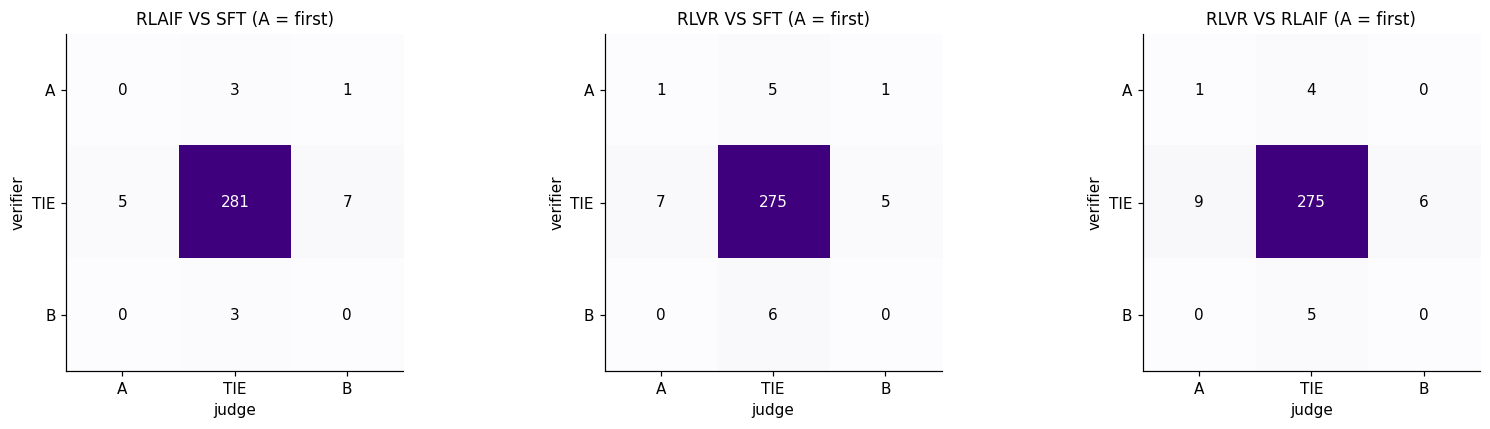

most frequent raw judge outputs (GSM8K): {'TIE': 384, 'A, B': 11, 'B': 7, 'A': 4, 'A, B,': 3}


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for a, (k, v) in zip(axes, PW.items()):
    C = np.array([[v["verifier_judge_contingency"][vv][jj] for jj in ["A", "TIE", "B"]] for vv in ["A", "TIE", "B"]])
    a.imshow(C, cmap="Purples"); a.grid(False)
    for i in range(3):
        for j in range(3):
            a.text(j, i, C[i, j], ha="center", va="center", color="white" if C[i, j] > C.max() / 2 else "black")
    a.set_xticks(range(3)); a.set_xticklabels(["A", "TIE", "B"]); a.set_yticks(range(3)); a.set_yticklabels(["A", "TIE", "B"])
    a.set_xlabel("judge"); a.set_ylabel("verifier"); a.set_title(k.replace("_vs_", " vs ").upper() + " (A = first)")
fig.tight_layout(); plt.show()
if AMB: print("most frequent raw judge outputs (GSM8K):", AMB["gsm"]["all_raw_outputs"])

## 4. Examples where verifier and judge disagree

In [10]:
items = load("task5_feedback/math_pairwise_items_gsm.json")["rlaif_vs_sft"]
byid = {p: Gn[p].set_index("id") for p in POL}
shown = 0
for it in items:
    if it["verifier"] != "TIE" and it["judge"] != "TIE" and it["judge"] != it["verifier"] and shown < 2:
        a, b = byid["rlaif"].loc[it["id"]], byid["sft"].loc[it["id"]]
        side_by_side(f"judge prefers {'RLAIF' if it['judge'] == 'A' else 'SFT'}, verifier prefers {'RLAIF' if it['verifier'] == 'A' else 'SFT'} (gold {a.gold})", a.problem,
                     {"RLAIF": a.response, "SFT": b.response}, meta={"RLAIF": f"correct {a.exact_correct} · pred {a.pred_final}", "SFT": f"correct {b.exact_correct} · pred {b.pred_final}"}, limit=600)
        shown += 1
if not shown: print("no pair with opposite decisive preferences")

RLAIFcorrect True · pred 1Step 1: Calculate the total cost for Becky.Becky bought 20 apples at 45 cents each.Total cost = Number of apples × Price per appleTotal cost = 20 × 0.45Total cost = $9Step 2: Apply the discount to Becky's total cost.Becky received a $1 discount on her purchase.Discounted total = Total cost - DiscountDiscounted total = $9 - $1Discounted total = $8Step 3: Calculate the total cost for Kelly.Kelly bought 20 apples at 50 cents each.Total cost = Number of apples × Price per appleTotal cost = 20 × 0.50Total cost = $10Step 4: Apply the discount to Kelly's total cost.Kelly received a …,SFTcorrect False · pred nanStep 1: Calculate the total cost for Becky.Becky bought 20 apples at 45 cents each.Total cost = Number of apples × Price per appleTotal cost = 20 × 0.45Total cost = $9Step 2: Apply the discount to Becky's total cost.Becky received a $1 discount on her purchase.Discounted total = Total cost - DiscountDiscounted total = $9 - $1Discounted total = $8Step 3: Calculate the total cost for Kelly.Kelly bought 20 apples at 50 cents each.Total cost = Number of apples × Price per appleTotal cost = 20 × 0.50Total cost = $10Step 4: Apply the discount to Kelly's total cost.Kelly received a …


## 5. Facts for RQ1

In [11]:
v = PW["rlaif_vs_sft"]
print(f"verifier decisive on {v['n_verifier_decisive']}/{v['n']} RLAIF-vs-SFT pairs; judge decisive on {round((1 - v['tie_rate']) * v['n'])}/{v['n']}")
print(f"judge decisive when verifier ties: {v['judge_decisive_when_verifier_tie']:.3f}; judge prefers the longer response in those cases: {v['judge_prefers_longer_when_verifier_tie']}")
print(f"judge cost: {E['judge_cost']['mean_seconds_per_call']:.2f} s per uncached call ({E['judge_cost']['uncached_calls']} calls)")

verifier decisive on 7/300 RLAIF-vs-SFT pairs; judge decisive on 13/300
judge decisive when verifier ties: 0.041; judge prefers the longer response in those cases: 0.6666666666666666
judge cost: 0.50 s per uncached call (409 calls)
